<a href="https://colab.research.google.com/github/Abdulaziz-Alsuhaimi/COE486-Vehicle-Damage-Detection/blob/main/CV_ProjectCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install dependencies
!pip install -q ultralytics kagglehub

import ultralytics
ultralytics.checks()

print("\u2705 Setup complete")


Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)
✅ Setup complete


In [ ]:
# Cell 2: Download the CarDD dataset (public dataset — no Kaggle account or token needed)
import kagglehub

dataset_dir = kagglehub.dataset_download(
    "gabrielfcarvalho/cardd-with-yolo-annotations-images-labels"
)

print("\u2705 Dataset downloaded to:", dataset_dir)
!ls "{dataset_dir}"


100%|██████████| 2.80G/2.80G [02:50<00:00, 17.6MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2
data.yaml  test  train	val


In [ ]:
# Cell 3: Point data.yaml at the downloaded dataset
import glob
import os
import yaml

matches = glob.glob(os.path.join(dataset_dir, '**', 'data.yaml'), recursive=True)
assert matches, f"data.yaml not found under {dataset_dir}"
DATA_YAML = matches[0]
dataset_root = os.path.dirname(DATA_YAML)

with open(DATA_YAML) as f:
    data = yaml.safe_load(f)

print("Original yaml:", data)

for split in ('train', 'val', 'test'):
    split_dir = os.path.join(dataset_root, split, 'images')
    assert os.path.isdir(split_dir), f"Missing expected folder: {split_dir}"
    data[split] = split_dir

with open(DATA_YAML, 'w') as f:
    yaml.dump(data, f)

TEST_IMAGES_DIR = data['test']

print("\n\u2705 Fixed yaml:")
print(f"  Train: {data['train']}")
print(f"  Val:   {data['val']}")
print(f"  Test:  {data['test']}")
print(f"  Classes ({data['nc']}): {data['names']}")


Original yaml: {'train': '/kaggle/input/cardd-with-yolo-annotations-images-labels/train/images', 'val': '/kaggle/input/cardd-with-yolo-annotations-images-labels/val/images', 'test': '/kaggle/input/cardd-with-yolo-annotations-images-labels/test/images', 'nc': 6, 'names': ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']}

✅ Fixed yaml:
  Train: /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/train/images
  Val:   /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/val/images
  Test:  /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/test/images
  Classes (6): ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


In [ ]:
# Cell 4: Train Baseline YOLOv8s
from ultralytics import YOLO

baseline_model = YOLO('yolov8s.pt')

baseline_model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=32,
    name='baseline_yolov8s',
    project='/content/runs',
    patience=5,
    seed=0,
    verbose=True,
)

print("\u2705 Baseline training complete")


Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bas

In [ ]:
# Cell 5: Evaluate the baseline on the held-out TEST split (best.pt, not last epoch)
from ultralytics import YOLO

baseline_best = YOLO('/content/runs/baseline_yolov8s/weights/best.pt')
baseline_metrics = baseline_best.val(
    data=DATA_YAML,
    split='test',
    name='baseline_test',
    project='/content/runs',
)

baseline_vals = {
    'mAP@0.5':      baseline_metrics.box.map50,
    'mAP@0.5:0.95': baseline_metrics.box.map,
    'Precision':    baseline_metrics.box.mp,
    'Recall':       baseline_metrics.box.mr,
}

print("=== Baseline YOLOv8s — test split ===")
for k, v in baseline_vals.items():
    print(f"  {k:<14} {v:.4f}")


Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 132.9±18.0 MB/s, size: 628.6 KB)
val: Scanning /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/test/labels... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 499.4it/s 0.7s
val: New cache created: /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.8it/s 8.5s
                   all        374        785      0.687      0.635      0.681      0.509
                  dent        157        236      0.582       0.53      0.551       0.32
               scratch        183        307      0.605      0.531      0.577      0.315
    

In [2]:
# Cell 6: Define CBAM and a trainer that injects it so it SURVIVES training.
#
# Why the trainer override: YOLO.train() rebuilds the model from its yaml and
# re-loads weights by name, so modules attached to model.model beforehand are
# silently discarded (the tell in the old logs: "Transferred 313/355" and a
# parameter count identical to the baseline). DetectionTrainer.get_model() is
# the supported place for architecture surgery — it runs AFTER the rebuilt
# model has loaded its pretrained weights.
import torch
import torch.nn as nn
from ultralytics.models.yolo.detect import DetectionTrainer


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, max_], dim=1))) * x


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


class LayerWithCBAM(nn.Module):
    """Wraps a backbone layer and applies CBAM to its output."""

    def __init__(self, layer, cbam):
        super().__init__()
        self.layer = layer
        self.cbam = cbam

    def forward(self, x):
        return self.cbam(self.layer(x))


class CBAMTrainer(DetectionTrainer):
    def get_model(self, cfg=None, weights=None, verbose=True):
        model = super().get_model(cfg=cfg, weights=weights, verbose=verbose)
        c2f = model.model[4]  # backbone stage-2 C2f (128 channels)
        cbam = CBAM(c2f.cv2.conv.out_channels)
        wrapped = LayerWithCBAM(c2f, cbam)
        # keep the graph bookkeeping the YOLO forward pass relies on
        wrapped.f, wrapped.i, wrapped.type = c2f.f, c2f.i, 'LayerWithCBAM'
        wrapped.np = sum(p.numel() for p in wrapped.parameters())
        model.model[4] = wrapped
        n_extra = sum(p.numel() for p in cbam.parameters())
        print(f"\u2705 CBAM injected after backbone layer 4 (+{n_extra:,} parameters)")
        return model


print("\u2705 CBAM modules and CBAMTrainer defined")


✅ CBAM modules and CBAMTrainer defined


In [ ]:
# Cell 7: Train YOLOv8s + CBAM (same settings as baseline)
# Watch the log for the "CBAM injected" line and "Transferred 349/355 items"
# (same transfer count as the baseline — nothing lost to renaming).
from ultralytics import YOLO

cbam_model = YOLO('yolov8s.pt')

cbam_model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=32,
    name='cbam_yolov8s',
    project='/content/runs',
    patience=5,
    seed=0,
    verbose=True,
    trainer=CBAMTrainer,
)

print("\u2705 CBAM training complete")


Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cba

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      6.97G      1.745       4.71      1.906         70        640: 100% ━━━━━━━━━━━━ 88/88 1.1s/it 1:33
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.0it/s 12.7s
                   all        810       1744      0.659      0.339      0.335      0.206

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10      7.55G      1.694      2.547      1.837         57        640: 100% ━━━━━━━━━━━━ 88/88 1.2it/s 1:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 11.5s
                   all        810       1744      0.649      0.367      0.376      0.232

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

       8/10      6.79G       1.29      1.649      1.508         70        640: 100% ━━━━━━━━━━━━ 88/88 1.2it/s 1:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 11.6s
                   all        810       1744      0.629      0.588      0.598      0.459

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      6.79G      1.222      1.525      1.453         89        640: 100% ━━━━━━━━━━━━ 88/88 1.2it/s 1:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 12.0s
                   all        810       1744       0.66      0.628      0.636      0.491

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      6.79G      1.149      1.396        1.4         63        640: 100% ━━━━━━━━━━━━ 88/88 1.2it/s 1:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 12.3s
                   all        810       1744      0.689       0.63      0.666      0.518

10 epochs completed in 0.252 hours.
Optimizer stripped from /content/runs/cbam_yolov8s/weights/last.pt, 22.5MB
Optimizer stripped from /content/runs/cbam_yolov8s/weights/best.pt, 22.5MB

Validating /content/runs/cbam_yolov8s/weights/best.pt...
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 81 layers, 11,130,052 parameters, 0 gradients, 28.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.0s/it 13.6s
                   all        810       1744      0.689      0.629      0.666      0.519
                  dent        352       

In [ ]:
# Cell 8: Evaluate YOLOv8s + CBAM on the same TEST split
from ultralytics import YOLO

cbam_best = YOLO('/content/runs/cbam_yolov8s/weights/best.pt')
cbam_metrics = cbam_best.val(
    data=DATA_YAML,
    split='test',
    name='cbam_test',
    project='/content/runs',
)

cbam_vals = {
    'mAP@0.5':      cbam_metrics.box.map50,
    'mAP@0.5:0.95': cbam_metrics.box.map,
    'Precision':    cbam_metrics.box.mp,
    'Recall':       cbam_metrics.box.mr,
}

print("=== YOLOv8s + CBAM — test split ===")
for k, v in cbam_vals.items():
    print(f"  {k:<14} {v:.4f}")

print("\n=== Per-class mAP@0.5 ===")
names = cbam_best.names
for idx, ap in zip(cbam_metrics.box.ap_class_index, cbam_metrics.box.ap50):
    print(f"  {names[int(idx)]:<16} {ap:.3f}")


Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 81 layers, 11,130,052 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 137.1±10.7 MB/s, size: 639.0 KB)
val: Scanning /root/.cache/kagglehub/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels/versions/2/test/labels.cache... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 142.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.6it/s 9.2s
                   all        374        785      0.606      0.683      0.684      0.513
                  dent        157        236      0.518      0.581      0.573      0.322
               scratch        183        307      0.542      0.573      0.547      0.291
                 crack         48         70       0.48      0.343      0.344      0.167
         glass shatter         71         71      0.

Metric                 Baseline       CBAM     Change
mAP@0.5                  0.6812     0.6837 ▲     0.4%
mAP@0.5:0.95             0.5093     0.5127 ▲     0.7%
Precision                0.6867     0.6060 ▼    11.7%
Recall                   0.6351     0.6833 ▲     7.6%

README table (markdown):

| Metric | Baseline YOLOv8s | YOLOv8s + CBAM | Change |
|---|---|---|---|
| mAP@0.5 | 0.681 | 0.684 | ▲ 0.4% |
| mAP@0.5:0.95 | 0.509 | 0.513 | ▲ 0.7% |
| Precision | 0.687 | 0.606 | ▼ 11.7% |
| Recall | 0.635 | 0.683 | ▲ 7.6% |

| Class | mAP@0.5 |
|---|---|
| dent | 0.573 |
| scratch | 0.547 |
| crack | 0.344 |
| glass shatter | 0.979 |
| lamp broken | 0.754 |
| tire flat | 0.906 |


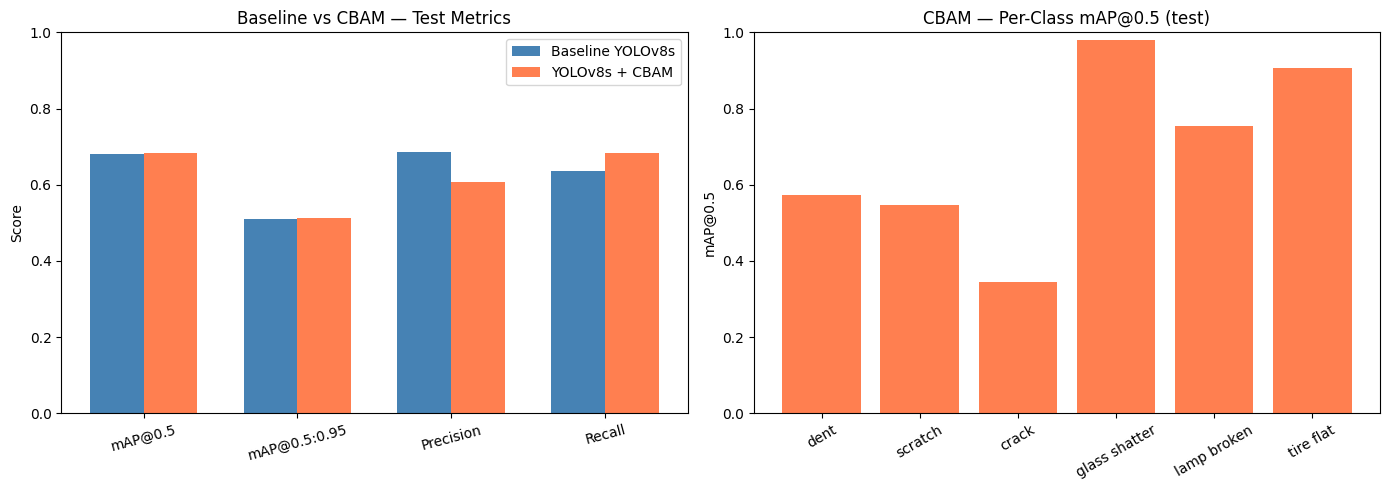


✅ Chart saved to /content/comparison_chart.png


In [ ]:
# Cell 9: Compare baseline vs CBAM — computed from the runs above, nothing hardcoded
import numpy as np
import matplotlib.pyplot as plt

try:
    baseline_vals, cbam_vals
except NameError:
    raise RuntimeError("Run Cells 5 and 8 first so both models have test metrics.")

print("=" * 52)
print(f"{'Metric':<20} {'Baseline':>10} {'CBAM':>10} {'Change':>10}")
print("=" * 52)
for key in baseline_vals:
    b, c = baseline_vals[key], cbam_vals[key]
    change = (c - b) / b * 100
    arrow = "\u25b2" if change >= 0 else "\u25bc"
    print(f"{key:<20} {b:>10.4f} {c:>10.4f} {arrow}{abs(change):>8.1f}%")
print("=" * 52)

# Markdown table ready to paste into README.md
print("\nREADME table (markdown):\n")
print("| Metric | Baseline YOLOv8s | YOLOv8s + CBAM | Change |")
print("|---|---|---|---|")
for key in baseline_vals:
    b, c = baseline_vals[key], cbam_vals[key]
    change = (c - b) / b * 100
    arrow = "\u25b2" if change >= 0 else "\u25bc"
    print(f"| {key} | {b:.3f} | {c:.3f} | {arrow} {abs(change):.1f}% |")

per_class = {
    cbam_best.names[int(idx)]: ap
    for idx, ap in zip(cbam_metrics.box.ap_class_index, cbam_metrics.box.ap50)
}
print("\n| Class | mAP@0.5 |")
print("|---|---|")
for cls, ap in per_class.items():
    print(f"| {cls} | {ap:.3f} |")

# Chart 1: overall metric comparison / Chart 2: per-class mAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names = list(baseline_vals.keys())
x = np.arange(len(metric_names))
width = 0.35
axes[0].bar(x - width / 2, list(baseline_vals.values()), width,
            label='Baseline YOLOv8s', color='steelblue')
axes[0].bar(x + width / 2, list(cbam_vals.values()), width,
            label='YOLOv8s + CBAM', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].set_title('Baseline vs CBAM — Test Metrics')
axes[0].legend()
axes[0].set_ylabel('Score')

axes[1].bar(per_class.keys(), per_class.values(), color='coral')
axes[1].set_title('CBAM — Per-Class mAP@0.5 (test)')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('mAP@0.5')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n\u2705 Chart saved to /content/comparison_chart.png")


Using Colab cache for faster access to the 'cardd-with-yolo-annotations-images-labels' dataset.
Using 3 test images from /kaggle/input/cardd-with-yolo-annotations-images-labels/test/images
✅ Broken Glass Specialist: 1 detections across 3 images
✅ Lamp Broken Specialist: 0 detections across 3 images
✅ Crack+Dent Specialist: 1 detections across 3 images


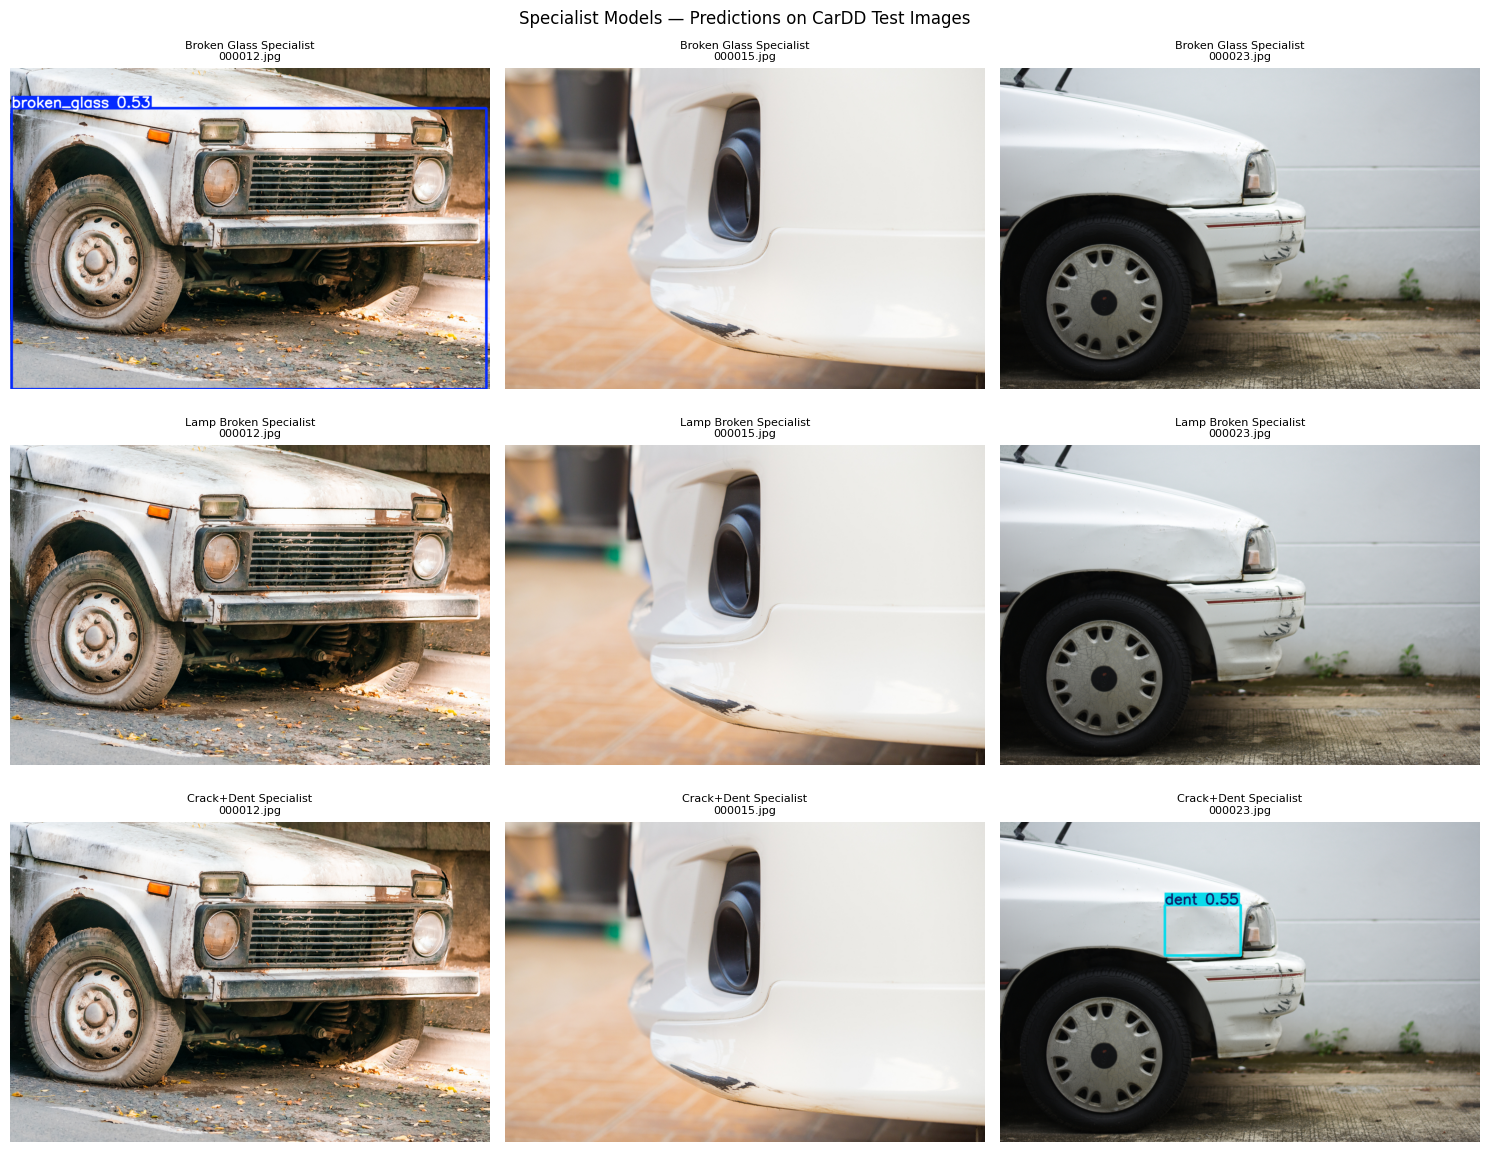


✅ Saved to /content/specialist_predictions.png


In [4]:
# Cell 10 (optional): Legacy single-class specialist models on sample test images
# Upload best_window.pt, best_lamp.pt, best_damage.pt to the Colab session first.
!pip install -q ultralytics kagglehub

from ultralytics import YOLO
import glob
import os
import re
import matplotlib.pyplot as plt

# Colab renames duplicate uploads to 'name (1).pt' — normalize that
for path in glob.glob('best_* (*).pt'):
    target = re.sub(r' \(\d+\)(?=\.pt$)', '', path)
    if not os.path.exists(target):
        os.rename(path, target)

try:
    img_dir = TEST_IMAGES_DIR  # set by Cell 3
except NameError:
    import kagglehub
    root = kagglehub.dataset_download(
        "gabrielfcarvalho/cardd-with-yolo-annotations-images-labels"
    )
    img_dir = glob.glob(os.path.join(root, '**', 'test', 'images'), recursive=True)[0]

test_images = (sorted(glob.glob(os.path.join(img_dir, '*.jpg')))[:3]
               or sorted(glob.glob(os.path.join(img_dir, '*.png')))[:3])
print(f"Using {len(test_images)} test images from {img_dir}")

models = {
    'best_window.pt': 'Broken Glass Specialist',
    'best_lamp.pt':   'Lamp Broken Specialist',
    'best_damage.pt': 'Crack+Dent Specialist',
}
available = {f: n for f, n in models.items() if os.path.exists(f)}
missing = sorted(set(models) - set(available))
if missing:
    print(f"\u26a0\ufe0f Skipping missing model files: {', '.join(missing)} "
          "(upload them to run all rows)")

if available and test_images:
    fig, axes = plt.subplots(len(available), len(test_images),
                             figsize=(5 * len(test_images), 4 * len(available)),
                             squeeze=False)
    for row, (model_file, name) in enumerate(available.items()):
        model = YOLO(model_file)
        results = model.predict(test_images, conf=0.25, verbose=False)
        n_boxes = sum(len(r.boxes) for r in results)
        for col, (img_path, result) in enumerate(zip(test_images, results)):
            axes[row][col].imshow(result.plot()[:, :, ::-1])
            axes[row][col].set_title(f"{name}\n{os.path.basename(img_path)}", fontsize=8)
            axes[row][col].axis('off')
        print(f"\u2705 {name}: {n_boxes} detections across {len(results)} images")

    plt.suptitle('Specialist Models — Predictions on CarDD Test Images', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/specialist_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n\u2705 Saved to /content/specialist_predictions.png")
else:
    print("Nothing to run — need at least one model file and one test image.")


✅ Unified CBAM model: 4 detections across 3 images


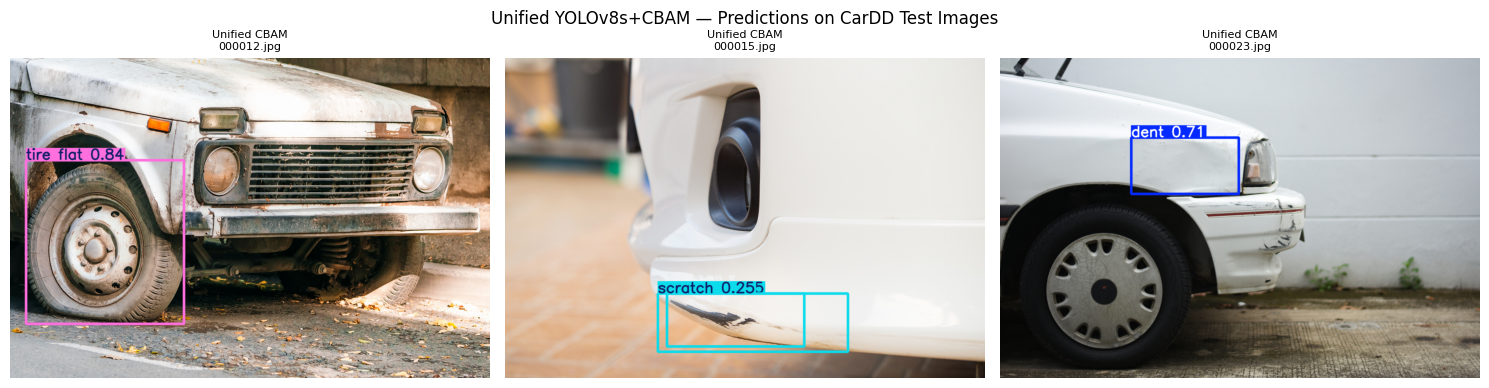

In [6]:
#Cell 11 (optional)
# Upload cbam_best.pt to Collab Session first

from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

model = YOLO('cbam_best.pt')
results = model.predict(test_images, conf=0.25, verbose=False)  # same 3 images as Cell 10

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 4))
for ax, img_path, result in zip(axes, test_images, results):
    ax.imshow(result.plot()[:, :, ::-1])
    ax.set_title(f"Unified CBAM\n{os.path.basename(img_path)}", fontsize=8)
    ax.axis('off')

n_boxes = sum(len(r.boxes) for r in results)
print(f"✅ Unified CBAM model: {n_boxes} detections across {len(results)} images")
plt.suptitle('Unified YOLOv8s+CBAM — Predictions on CarDD Test Images', fontsize=12)
plt.tight_layout()
plt.savefig('/content/cbam_predictions.png', dpi=150, bbox_inches='tight')
plt.show()